# Tensorflow
- TensorFlow is an open-source library developed by Google specifically for Deep Learning
- uses a dedicated data type Tensor, that can be used directly in the construction and training of neural networks. Tensors in TensorFlow are the fundamental data structure used for representing multi-dimentional arrays.
- TensorFlow has robust support for GPU acceleration, making it efficient for training depp learning models on GPUs.

Installlation 
https://www.tensorflow.org/install/pip#linux

In [1]:
import tensorflow as tf
import numpy as np

2026-03-06 18:17:27.788204: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-06 18:17:27.801969: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-06 18:17:28.349168: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-06 18:17:29.848498: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computat

In [2]:
tf.test.is_built_with_cuda()

True

In [3]:
tf.config.list_physical_devices('GPU')

2026-03-06 18:17:31.312256: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


[]

# Tensor: Constant vs Variable
- tf.constant/tf.Tensor: Constants are immutable, meaining their values cannot be changed after creation. Once you create a constant tensor, its value remains fixed throughout the execution of the program. Use them for example, if you have hyperparameters or fixed values that need to remain constant throughout the trining process.
- tf.Variable: Variables are mutable, and their values can be chnaged druing the execution of the program. This makes variables suitable for situations where you need to update the values iteratively, such as in training neural network wights. Use vairables when you want to represent trainable parameters in your model, like wights and biases in a neural network.

In [4]:
x1 = tf.constant([[1.0, 2.0]]) #, dtype=np.float16)
x1

<tf.Tensor: shape=(1, 2), dtype=float32, numpy=array([[1., 2.]], dtype=float32)>

In [5]:
x1.numpy()

array([[1., 2.]], dtype=float32)

In [6]:
print(x1[0])
print(x1[0][0])

tf.Tensor([1. 2.], shape=(2,), dtype=float32)
tf.Tensor(1.0, shape=(), dtype=float32)


In [7]:
y1 = tf.convert_to_tensor(np.array([2.0, 3.0]))
y1

<tf.Tensor: shape=(2,), dtype=float64, numpy=array([2., 3.])>

In [8]:
b1 = tf.constant(4.0)
b1

<tf.Tensor: shape=(), dtype=float32, numpy=4.0>

In [9]:
b1 = tf.Variable(4.0)
b1

<tf.Variable 'Variable:0' shape=() dtype=float32, numpy=4.0>

In [10]:
# Using tf.constant
constant_tensor = tf.constant([1,2,3])

# Using tf.Variable
variable_tensor = tf.Variable([1,2,3])

# You can update the value of a tf.Variable
variable_tensor.assign([4,5,6])

# Accessing the values
print("Constant Tensor:", constant_tensor.numpy()) # output: [1 2 3]
print("Variable Tensor:", variable_tensor.numpy()) # output: [4 5 6]

Constant Tensor: [1 2 3]
Variable Tensor: [4 5 6]


## Eager vs Graph execution / Інтерактивне (послідовне) виконання проти графічного виконання

https://wwww.tensorflow.org/guide/intro_to_graphs



In [11]:
# https://www.tensorflow.org/api_docs/python/tf/executing_eagerly
# Default
assert tf.multiply(2, 3) == 6
tf.executing_eagerly()

True

In [12]:
# Simple Python function
def fn():
    print("Eager execution in a simple Python function.", tf.executing_eagerly())
    return tf.multiply(2, 3).numpy()

fn()

Eager execution in a simple Python function. True


6

In [13]:
tf.config.run_functions_eagerly(False) # Default is False, so this is just to show how to set it explicitly
@tf.function # Compiles the function into a TensorFlow graph (https://www.tensorflow.org/api_docs/python/tf/function)
def fn_graph():
    with tf.init_scope(): # Context manager, moves clause out of the graph, so it will be executed in eager mode
        print("Eager execution in a tf.function.", tf.executing_eagerly()) # Outside of the graph, so it will be executed in eager mode
    print("Eager execution inside of the graph.", tf.executing_eagerly()) # Inside of the graph, so it will be executed in graph mode
    return tf.multiply(2, 3)#.numpy()
fn_graph().numpy()

Eager execution in a tf.function. True
Eager execution inside of the graph. False


6

In [14]:
tf.config.run_functions_eagerly(True) 
@tf.function # Compiles the function into a TensorFlow graph (https://www.tensorflow.org/api_docs/python/tf/function)
def fn_eager():
    with tf.init_scope(): # Context manager, moves clause out of the graph, so it will be executed in eager mode
        print("Eager execution in a tf.function.", tf.executing_eagerly()) # Outside of the graph, so it will be executed in eager mode
    print("Eager execution inside of the graph.", tf.executing_eagerly()) # Inside of the graph, so it will be executed in graph mode
    return tf.multiply(2, 3).numpy() # This will work because we are running functions eagerly, so the graph will be executed in eager mode
fn_eager()

Eager execution in a tf.function. True
Eager execution inside of the graph. True


6

In [15]:
# fn_eager().graph()

In [16]:
# Switch to graph mode by default
# tf.compat.v1.disable_eager_execution()

In [17]:
fn_eager() # -> no eager execution anymore

Eager execution in a tf.function. True
Eager execution inside of the graph. True


6

Good practice:

* use @tf.function decorator to define your functions and switch on the option tf.config.run_functions_eagerly(True) when debugging to be able to turn it to False otherwise if needed

# Computational graph / обчислювальний граф
https://wwww.tensorflow.org/guide/intro_to_graphs

In [18]:

def formula(x: tf.Tensor, y: tf.Tensor, b: tf.Tensor) -> tf.Tensor:
    x = tf.matmul(x, y)
    x = x+b
    return x


function_that_uses_a_graph = tf.function(formula)

x1 = tf.constant([[1.0, 2.0]])
y1 = tf.constant([[2.0], [3.0]])
b1 = tf.constant([4.0])

orig_value = formula(x1, y1, b1).numpy()
tf_function_value = function_that_uses_a_graph(x1, y1, b1).numpy()

assert (orig_value == tf_function_value)
orig_value == tf_function_value

array([[ True]])

In [19]:
def my_func(x,y):
    # A  simple hand-rolled layer.
    return tf.nn.relu(tf.matmul(x, y))

my_func_tf = tf.function(my_func)

my_func_tf(x=x1, y=y1).numpy()

array([[8.]], dtype=float32)

In [20]:
# This is the graph-generating output of AutoGraph.
print(tf.autograph.to_code(my_func_tf.python_function))

def tf__my_func(x, y):
    with ag__.FunctionScope('my_func', 'fscope', ag__.ConversionOptions(recursive=True, user_requested=True, optional_features=(), internal_convert_user_code=True)) as fscope:
        do_return = False
        retval_ = ag__.UndefinedReturnValue()
        try:
            do_return = True
            retval_ = ag__.converted_call(ag__.ld(tf).nn.relu, (ag__.converted_call(ag__.ld(tf).matmul, (ag__.ld(x), ag__.ld(y)), None, fscope),), None, fscope)
        except:
            do_return = False
            raise
        return fscope.ret(retval_, do_return)



In [21]:
# This is the graph itself
print(my_func_tf.get_concrete_function(x1, y1).graph.as_graph_def())

node {
  name: "x"
  op: "Placeholder"
  attr {
    key: "shape"
    value {
      shape {
        dim {
          size: 1
        }
        dim {
          size: 2
        }
      }
    }
  }
  attr {
    key: "dtype"
    value {
      type: DT_FLOAT
    }
  }
  attr {
    key: "_user_specified_name"
    value {
      s: "x"
    }
  }
}
node {
  name: "y"
  op: "Placeholder"
  attr {
    key: "shape"
    value {
      shape {
        dim {
          size: 2
        }
        dim {
          size: 1
        }
      }
    }
  }
  attr {
    key: "dtype"
    value {
      type: DT_FLOAT
    }
  }
  attr {
    key: "_user_specified_name"
    value {
      s: "y"
    }
  }
}
node {
  name: "MatMul"
  op: "MatMul"
  input: "x"
  input: "y"
  attr {
    key: "transpose_b"
    value {
      b: false
    }
  }
  attr {
    key: "transpose_a"
    value {
      b: false
    }
  }
  attr {
    key: "grad_b"
    value {
      b: false
    }
  }
  attr {
    key: "grad_a"
    value {
      b: false

https://www.tensorflow.org/tensorboard/graphs#graphs_of_tffunctions

1. Run in terminal ```tensorboard --logdir logs/graph_only``` (NB: naviate to the notebook directory prior to running the command)
2. Go to localhost: 6006 in browser

In [22]:
import tensorflow as tf
from datetime import datetime
import os

# 1. Create a directory 
logdir = "logs/graph_only/" + datetime.now().strftime("%Y%m%d-%H%M%S")
writer = tf.summary.create_file_writer(logdir)

@tf.function
def my_func(x, y):
    return tf.nn.relu(tf.matmul(x, y))

x = tf.random.uniform((3, 3))
y = tf.random.uniform((3, 3))

# 2. Use the concrete_function to extract the graph explicitly
with writer.as_default():
    # This manually pushes the graph structure to the log file
    tf.summary.graph(my_func.get_concrete_function(x, y).graph)

writer.close()
print(f"Direct graph written to: {logdir}")

Direct graph written to: logs/graph_only/20260306-181731


Швидкість виконання графа в TensorFlow порівняно з інтерактивним виконанням в основному залежить від наступних факторів:

- Оптимізація графа: Під час виконання графа TensorFlow може оптимізувати та перетворювати граф обчислень перед його виконанням. Цей процес оптимізації може включати усунення спільних підвиразів, складання констант та інші оптимізації на рівні графа.

- Розміщення пристроїв та паралельне виконання: Графічне виконання TensorFlow дозволяє ефективно розміщувати пристрої та виконувати обчислення паралельно. Граф обчислень може бути розділений на підграфи, які можуть виконуватися паралельно на кількох пристроях, таких як GPU або TPU.

- Компіляція у прискорений код: Коли використовується графічне виконання, TensorFlow має можливість компілювати граф обчислень в більш оптимізовану форму на низькому рівні, специфічні для певного обладнання.

- Зменшення накладень Python: Інтерактивне виконання включає в себе виконання операцій імперативно, що означає, що кожна операція виконується негайно в Python. Це може вводити накладення Python та обмежувати можливості оптимізації. На відміну від цього, під час графічного виконання граф будується та оптимізується перед виконанням, що зменшує необхідність у частих взаємодіях із інтерпретатором Python.

In [23]:
import timeit

x = tf.random.uniform(shape=[10, 10], minval=-1, maxval=2, dtype=tf.dtypes.int32)

def power(x, y):
    result = tf.eye(10, dtype=tf.dtypes.int32)
    for _ in range(y):
        result = tf.matmul(x, result)
    return result

print("Eager execution:", timeit.timeit(lambda: power(x, 100), number = 1000), "seconds")

Eager execution: 1.7263439810000136 seconds


In [24]:
power_as_graph = tf.function(power)
print("Graph execution:", timeit.timeit(lambda: power_as_graph(x, 100), number = 1000), "seconds")

Graph execution: 1.6987841059999482 seconds


Automatic defferentiation / автоматичне визначення похідної

In [25]:
def sigmoid(x):
    return 1 / (1 + tf.exp(-x)) 

x = tf.Variable(2.0)
with tf.GradientTape() as tape:
    y = sigmoid(x)
    dydx = tape.gradient(y, x)
    print("Gradient of sigmoid at x=2.0:", dydx.numpy())


Gradient of sigmoid at x=2.0: 0.104993574


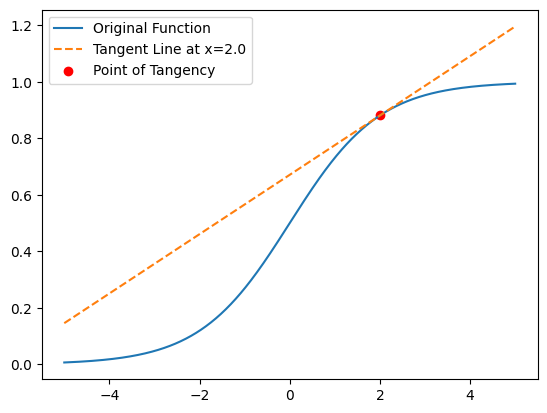

In [28]:
import matplotlib.pyplot as plt

# Define the input range
x_values = np.linspace(-5, 5, 1000)
y_values = sigmoid(x_values)

# Tangent line equation: y = f`(x) * (x - x0) + f(x0)
tangent_line = dydx*(x_values - x)+y

# Plot the function and its tangent line
plt.plot(x_values, y_values, label='Original Function')
plt.plot(x_values, tangent_line, label='Tangent Line at x={}'.format(x.numpy()), linestyle='--')
plt.scatter(x.numpy(), y.numpy(), color='red', label='Point of Tangency')
plt.legend()
plt.show()


# Simple Neural Network

In [ ]:
# y = w1*x + b1
class SimpleModule(tf.Module):
    def __init__(self, name=None):
        super().__init__(name=name)
        self.w = tf.Variable(5.0)
        self.b = tf.Variable(5.0)

    @tf.function
    def __call__(self, x):
        return self.w * x + self.b
    

simple_module = SimpleModule(name="simple")
simple_module(tf.constant(5.0)).numpy()

30.0

# Neural network (Perceptron/перцептрон)

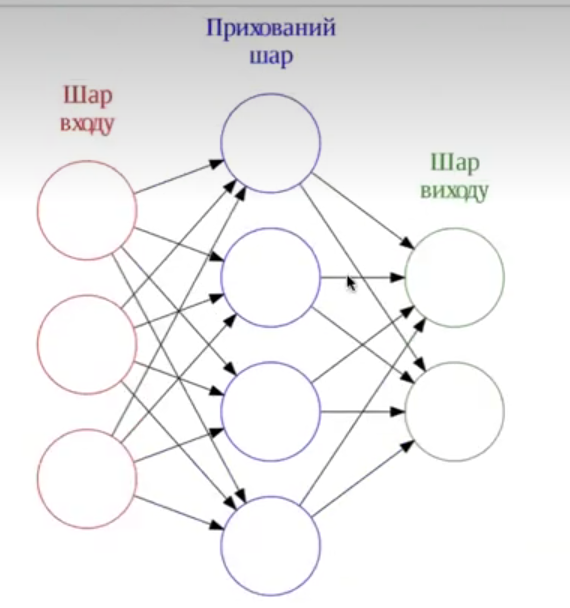


In [41]:
class DenseLayer(tf.Module):
    def __init__(self, in_features, out_features, name=None):
        super().__init__(name=name)
        self.w = tf.Variable(tf.random.normal([in_features, out_features]), name='w')
        #print(self.w)
        self.b = tf.Variable(tf.zeros([out_features]), name='biases') # Trainable variables
        #print(self.b)

    @tf.function
    def __call__(self, x):
        y= tf.matmul(x, self.w) + self.b
        return tf.nn.relu(y)
    

# Multi-layer perceptron
class NN(tf.Module):
    def __init__(self, name=None):
        super().__init__(name=name)
        self.layer1 = DenseLayer(in_features=3,out_features=3)
        self.layer2 = DenseLayer(in_features=3,out_features=1)

    #@tf.function
    def __call__(self, x):
        print("Input layer:", x)
        print("Layer 1:", "tf.nn.relu(", self.layer1.w.numpy(), "*", x.numpy(),"+", self.layer1.b.numpy()), ")"
        x = self.layer1(x)
        print("Layer 2:", "tf.nn.relu(", self.layer2.w.numpy(), "*", x.numpy(),"+", self.layer2.b.numpy()), ")"
        x=self.layer2(x)
        print("Layer 2 output:", x)
        return x
    
nn = NN(name="neural_network")
    

In [42]:
print("Results:", nn(tf.constant([[2.0, 2.0, 2.0]])))

Input layer: tf.Tensor([[2. 2. 2.]], shape=(1, 3), dtype=float32)
Layer 1: tf.nn.relu( [[-0.12030318  1.1151899   1.2439162 ]
 [-0.44870436  0.8884779   2.4706256 ]
 [-1.7119247   0.86226386  1.3097936 ]] * [[2. 2. 2.]] + [0. 0. 0.]
Layer 2: tf.nn.relu( [[-0.733022 ]
 [ 0.5614571]
 [-1.5896174]] * [[ 0.         5.7318635 10.048671 ]] + [0.]
Layer 2 output: tf.Tensor([[0.]], shape=(1, 1), dtype=float32)
Results: tf.Tensor([[0.]], shape=(1, 1), dtype=float32)


In [ ]:
def identity(x):
    return x

def step(x):
    return tf.where(x > 0, 1,0)

def sigmoid(x):
    return tf.math.sigmoid(x)

def tanh(x):
    return tf.math.tanh(x)

def arctan(x):
    return tf.math.atan(x)

def relu(x):
    return tf.nn.relu(x)

def prelu(x, alpha=0.1):
    return tf.maximum(0.0, x) + alpha * tf.minimum(0.0, x)

def softsign(x):
    return x / (1 + tf.abs(x))

# Linear Model

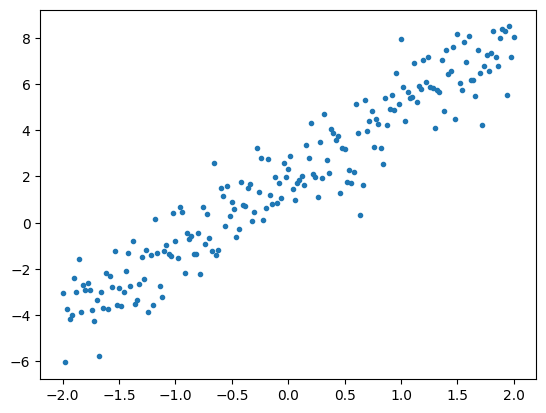

In [44]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# The actual line
TRUE_W = 3.0
TRUE_B = 2.0

NUM_EXAMPLES = 201

# A vector of random x values
x = tf.linspace(-2, 2, NUM_EXAMPLES)
x = tf.cast(x, dtype=tf.float32)

def f(x):
    return x * TRUE_W + TRUE_B

# Generate some noise
noise = tf.random.normal(shape=[NUM_EXAMPLES], mean=0.0, stddev=1.0)

# Calculate y
y = f(x) + noise

# Plot the data
plt.plot(x, y, '.')
plt.show()


In [45]:
# Module: https://www.tensorflow.org/api_docs/python/tf/keras/Model
class LinearModel(tf.Module):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # Initialize weights to '5.0' and bias to '0.0'
        # In practice, these should be randomly initialized and trained using an optimization algorithm like gradient descent
        self.w = tf.Variable(5.0)
        self.b = tf.Variable(0.0)

    def __call__(self, x):
        return self.w * x + self.b
    
model = LinearModel(name="linear_model")
# List the variables tf.modules's built-in variable aggregation method
print("Model variables and biases:", model.variables)

# Verify the model works
assert model(3.0).numpy() == 5.0 * 3.0 + 0.0

Model variables and biases: (<tf.Variable 'Variable:0' shape=() dtype=float32, numpy=0.0>, <tf.Variable 'Variable:0' shape=() dtype=float32, numpy=5.0>)


In [49]:
def loss(target_y, predicted_y):
    return tf.reduce_mean(tf.square(target_y - predicted_y))


def train(model, x, y, learning_rate=0.01):
    # backpropagation
    with tf.GradientTape() as tape:
        current_loss = loss(y, model(x))
    dw, db = tape.gradient(current_loss, [model.w, model.b])
    model.w.assign_sub(learning_rate * dw)
    model.b.assign_sub(learning_rate * db)

def training_loop(model, x, y):
    for epoch in range(10):
        train(model, x, y, learning_rate=0.1)
        current_loss = loss(y, model(x))
        print(f"Epoch {epoch}: Loss: {current_loss.numpy()}, w: {model.w.numpy()}, b: {model.b.numpy()}")

In [50]:
linear_model = LinearModel(name="linear_model")
training_loop(linear_model, x, y)

Epoch 0: Loss: 6.313603401184082, w: 4.462634086608887, b: 0.3801822364330292
Epoch 1: Loss: 4.1470417976379395, w: 4.069998741149902, b: 0.6843279600143433
Epoch 2: Loss: 2.9020166397094727, w: 3.7831132411956787, b: 0.9276446104049683
Epoch 3: Loss: 2.180783748626709, w: 3.573495388031006, b: 1.1222978830337524
Epoch 4: Loss: 1.7595460414886475, w: 3.420334577560425, b: 1.2780205011367798
Epoch 5: Loss: 1.511496663093567, w: 3.308425188064575, b: 1.4025986194610596
Epoch 6: Loss: 1.3642462491989136, w: 3.226656675338745, b: 1.5022611618041992
Epoch 7: Loss: 1.2761462926864624, w: 3.1669111251831055, b: 1.581991195678711
Epoch 8: Loss: 1.2230401039123535, w: 3.1232571601867676, b: 1.6457751989364624
Epoch 9: Loss: 1.1908023357391357, w: 3.091360569000244, b: 1.6968023777008057


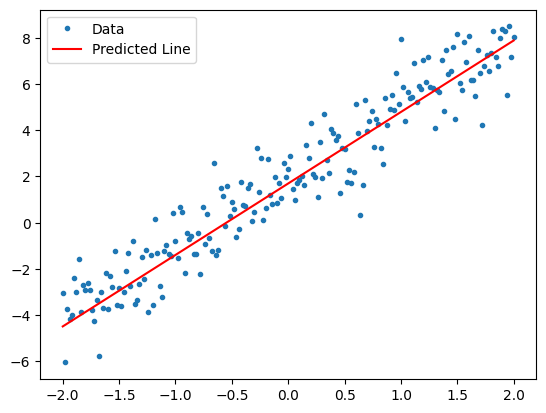

In [51]:
y_pred = linear_model(x)

# Plot all the data
plt.plot(x, y, '.', label='Data')
plt.plot(x, y_pred, label='Predicted Line', color='red')
plt.legend()
plt.show()

In [52]:
import torch


In [53]:
torch.cuda.is_available()

False

In [56]:
# Using torch.tensor (similar to tf.constant)
constant_tensor = torch.tensor([1,2,3])

# Using torch.nn.Parameter (similar to tf.Variable)
variable_tensor = torch.nn.Parameter(torch.tensor([1,2,3], dtype=torch.float32))

# If you want to create a regular tensor (not a parameter) with requires_grad=True, you can do so like this:
variable_tensor_non_param = torch.tensor([1,2,3], dtype=torch.float32, requires_grad=True)

# Print the tensors to verify
print("Constant Tensor:", constant_tensor) # output: tensor([1, 2, 3])
print("Variable Tensor:", variable_tensor) # output: Parameter containing: tensor([1, 2, 3], requires_grad=True)
print("Variable Tensor (non-Parameter):", variable_tensor_non_param) # output: tensor([1., 2., 3.], requires_grad=True)

Constant Tensor: tensor([1, 2, 3])
Variable Tensor: Parameter containing:
tensor([1., 2., 3.], requires_grad=True)
Variable Tensor (non-Parameter): tensor([1., 2., 3.], requires_grad=True)


In [ ]:
class LinearModel(torch.nn.Module):
    def __init__(self):
        super(LinearModel, self).__init__()
        # Initialize weights to '5.0' and bias to '0.0'
        # In practice, these should be randomly initialized and trained using an optimization algorithm like gradient descent
        self.w = torch.nn.Parameter(torch.tensor(5.0))
        self.b = torch.nn.Parameter(torch.tensor(0.0))

    def forward(self, x):
        return self.w * x + self.b
    
model = LinearModel()

def loss(target_y, predicted_y): # Mean Squared Error
    return torch.mean((target_y - predicted_y) ** 2)

def train(model, x, y, learning_rate=0.01):
    # BAcckopropagation, good explanation https://medium.com/@mugeshk/backpropagation_algorithm-using-pytorch-ee1287888aca
    current_loss = loss(y, model(x))
    model.zero_grad() # Clear gradients before backward pass (Обнуляємо параметри похідних перед зворотнім проходом)
    current_loss.backward() # Compute gradients https://pytorch.org/docs/stable/generated/torch.Tensor.backward.html

    with torch.no_grad(): # Update weights and biases without tracking gradients
        model.w -= learning_rate * model.w.grad
        model.b -= learning_rate * model.b.grad

def training_loop(model, x, y):
    for epoch in range(10):
        train(model, x, y, learning_rate=0.1)
        current_loss = loss(y, model(x))
        print(f"Epoch {epoch}: Loss: {current_loss.item()}, w: {model.w.item()}, b: {model.b.item()}")

# Please note that PyTorch uses dynamic computation graphs, so you don't need to explicitly define a graph like in TensorFlow. 
# The operations are executed immediately as they are called, which is why it's often referred to as "eager execution" by default.
# The gradients are automatically calculated during the backward pass, and you can access them through the .grad attribute of the parameters after calling backward() on the loss.
# Also, the loss function and the training loop have been adjusted to use PyTorch's syntax and conventions.

Epoch 0: Loss: 6.5476765632629395, w: 4.462315559387207, b: 0.4039730727672577
Epoch 1: Loss: 4.272073745727539, w: 4.069447040557861, b: 0.7271515130996704
Epoch 2: Loss: 2.957430839538574, w: 3.782391309738159, b: 0.9856942892074585
Epoch 3: Loss: 2.19173264503479, w: 3.5726492404937744, b: 1.192528486251831
Epoch 4: Loss: 1.7420848608016968, w: 3.4193975925445557, b: 1.357995867729187
Epoch 5: Loss: 1.4758788347244263, w: 3.307421922683716, b: 1.4903697967529297
Epoch 6: Loss: 1.3170217275619507, w: 3.225605010986328, b: 1.596268892288208
Epoch 7: Loss: 1.2215006351470947, w: 3.1658241748809814, b: 1.6809881925582886
Epoch 8: Loss: 1.163649082183838, w: 3.1221442222595215, b: 1.7487635612487793
Epoch 9: Loss: 1.1283762454986572, w: 3.090228796005249, b: 1.8029838800430298


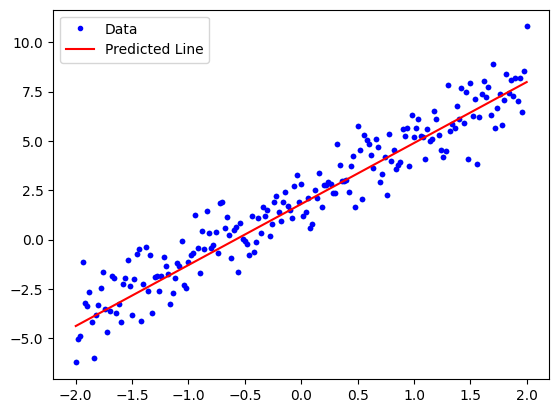

In [61]:
# Example usage:

# A vector of random x values
NUM_EXAMPLES = 201
x = torch.linspace(-2, 2, steps=NUM_EXAMPLES, dtype=torch.float32)

# Generate some noise
noise = torch.randn(NUM_EXAMPLES)

# The actual line
TRUE_W = 3.0
TRUE_B = 2.0

def f(x):
    return x * TRUE_W + TRUE_B

# Calculate y
y = f(x) + noise

# Plot the data
plt.plot(x.numpy(), y.numpy(), '.')

linear_model = LinearModel()
training_loop(linear_model, x, y)
y_pred = linear_model(x).detach().numpy() # Detach from the computation graph and convert to numpy for plotting
# Plot all the data
plt.plot(x.numpy(), y.numpy(), '.', label='Data', color='blue')
plt.plot(x.numpy(), y_pred, label='Predicted Line', color='red')
plt.legend()
plt.show()



# Which framework to use?

PyTorch and TensorFlow are two of the most popular deep learning frameworks, and while they share many similarities, there are some key differences between them:

<b>Dynamic vs. Static Computational Graph:</b>

- PyTorch: PyTorch uses a dynamic computational graph. This means that the graph is built on-the-fly as operations are executed. It allows for more flexibility and ease of debugging.

- TensorFlow: TensorFlow traditionally used a static computational graph. However, with the introduction of TensorFlow 2.x, eager execution became the default mode, providing a dynamic graph similar to PyTorch. TensorFlow 2.x allows users to switch between static and dynamic graphs.

<b>API Style:</b>

- PyTorch: PyTorch uses a more imperative and Pythonic syntax. It is often considered more intuitive and easier to learn for researchers and beginners.

- TensorFlow: TensorFlow has a more declarative and somewhat more verbose syntax. However, TensorFlow 2.x with eager execution is more similar to PyTorch in terms of syntax.

<b>Community and Adoption:</b>

- PyTorch: PyTorch gained popularity in the research community, and many researchers appreciate its dynamic graph and ease of use. It is often the preferred choice for prototyping and experimentation.

- TensorFlow: TensorFlow has been widely adopted in both research and industry. Its static graph mode was historically favored in production settings, and TensorFlow's ecosystem includes many tools for deploying models at scale.

<b>Visualization Tools:</b>
- PyTorch: PyTorch's models can also be visualized in TensorBoard
- TensorFlow: TensorFlow has TensorBoard, which is a powerful visualization tool for monitoring and debugging models during training. It includes features for graph visualization, loss curves, and more.

<b>Ecosystem and Integration</b>
- PyTorch: has a more concise and modular exosystem. It is often praised for its ease of integration with other libraries and tools
- TensorFlow has  a more extensive ecosystem, including TensorFlow Extended (TXF) for end-to-end machine learning pipelines. It is well-integrated with TensorFlow Lite for mobile and edge devices.

<b>Automatic Differentiation</b>
- PyTorch uses dynamic computation for automatic differentiation, making it easy to compute gradients of complex operations on-the-fly.
- TensorFlow: eager execution mode and TensorFlow 2.x make automatic differentiation more similar to PyTorch


Additional information: https://www.datacamp.com/tutorial/pytorch-vs-tensorflow-vs-keras